# Hedging

This notebook starts the hedging implementation for the swing-option study.

It is intentionally a phase-1 workflow:
- build or load a compact shared RL and LSM hedging cache on common HHK evaluation paths
- estimate a frozen-policy proxy hedge from the cached pathwise continuation values
- compare no-cost vanilla hedging, convex-cost delta-vs-spot behavior, and transaction-cost misspecification risk
- finish with a first-pass review list of concrete improvements

The implementation is explicit about scope: this is not yet the full nested Monte Carlo dynamic hedge from the draft in `Paper/Hedging.tex`. It is a practical first pass built on the repo's existing evaluators and saved runs.

## 1. Import Dependencies

Import the notebook, plotting, and project modules needed for cache building, proxy hedge estimation, and risk summaries.

In [1]:
import os
import subprocess
import sys
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "Jupyter Notebooks":
    REPO_ROOT = REPO_ROOT.parent
elif REPO_ROOT.name != "DRL-Swing-Options":
    REPO_ROOT = Path("/Users/alexanderithakis/Documents/GitHub/DRL-Swing-Options")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.hedging_utils import compute_pnl_risk_metrics

pd.options.display.float_format = "{:,.4f}".format
sns.set_theme(style="whitegrid", context="talk")

## 2. Define Configuration

Set the hedge build mode, cache location, selected experiment configurations, and plotting controls. The default is a smoke-sized build that still exercises all three analysis sections.

In [2]:
NOTEBOOK_PATH = REPO_ROOT / "Jupyter Notebooks" / "Hedging.ipynb"
DEFAULT_CONFIGS = [
    "SwingOption_20_c0.00_gamma1",
    "SwingOption_20_c0.04_gamma1",
    "SwingOption_20_c0.04_gamma1.5",
    "SwingOption_20_c0.04_gamma2",
]
METHODS = ("RL", "LSM")
SMOKE_MODE = True
FORCE_REBUILD = False
CACHE_ROOT = REPO_ROOT / "logs" / ("hedging_cache_smoke_notebook" if SMOKE_MODE else "hedging_cache")
BUILD_CONFIGS = tuple(DEFAULT_CONFIGS)
MAX_SEEDS = 1 if SMOKE_MODE else 0
N_PATHS_EVAL = 128 if SMOKE_MODE else 65536
LSM_TRAIN_PATHS = 256 if SMOKE_MODE else 65536
EVAL_BATCH_SIZE = 64 if SMOKE_MODE else 4096
LSM_BASIS = "chebyshev"
LSM_DEGREE = 2
LSM_REG = "none"
LSM_REG_ALPHA = 1e-6
LSM_N_ACTIONS = 5
DELTA_SLICE_TIME_STEP = 10
DELTA_BINS = 30
DELTA_SMOOTH_WINDOW = 7
NEAR_MATURITY_DAYS = 5
PNL_HIST_BINS = 72
NO_COST_BASELINE = "SwingOption_20_c0.00_gamma1"
MISSPECIFICATION_TARGET = "SwingOption_20_c0.04_gamma2"
VA_GRID = np.linspace(0.0, 1.0, 21)
BOOTSTRAP_RESAMPLES = 400 if SMOKE_MODE else 2000
BOOTSTRAP_CONFIDENCE = 0.95
BOOTSTRAP_SEED = 20260523
PLOT_COLORS = {
    "RL": "#0f3d5e",
    "LSM": "#6b5b2a",
    "unhedged": "#8c1d40",
    "hedged": "#1f4e79",
    "tc-aware": "#006d77",
    "tc-unaware": "#9c6644",
    "variance-aware": "#2d6a4f",
}
CONFIG_PALETTE = {
    "SwingOption_20_c0.00_gamma1": "#4c78a8",
    "SwingOption_20_c0.04_gamma1": "#f58518",
    "SwingOption_20_c0.04_gamma1.5": "#54a24b",
    "SwingOption_20_c0.04_gamma2": "#e45756",
}
CONFIG_LABELS = {
    "SwingOption_20_c0.00_gamma1": "Baseline (c=0)",
    "SwingOption_20_c0.04_gamma1": "c=0.04, gamma_c=1",
    "SwingOption_20_c0.04_gamma1.5": "c=0.04, gamma_c=1.5",
    "SwingOption_20_c0.04_gamma2": "c=0.04, gamma_c=2",
}
NO_COST_SCENARIO_LABELS = {
    "unhedged": "Unhedged liability",
    "hedged": "Proxy forward hedge",
}
MISSPEC_SCENARIO_LABELS = {
    "unhedged": "Unhedged liability",
    "tc-aware": "TC-aware hedge",
    "tc-unaware": "TC-unaware hedge",
    "variance-aware": "Variance-aware hedge",
}
REQUIRED_TRACE_COLUMNS = {
    "config",
    "method",
    "seed",
    "path",
    "time_step",
    "spot",
    "X_t",
    "Y_t",
    "reward_discounted",
    "forward_contract_maturity",
    "discount_factor_step",
}

print(f"Notebook path: {NOTEBOOK_PATH}")
print(f"Kernel executable: {sys.executable}")
print(f"Conda env: {os.environ.get('CONDA_DEFAULT_ENV', '<unknown>')}")
print(f"Smoke mode: {SMOKE_MODE}")
print(f"Cache root: {CACHE_ROOT}")
print(f"Configs: {BUILD_CONFIGS}")

Notebook path: /Users/alexanderithakis/Documents/GitHub/DRL-Swing-Options/Jupyter Notebooks/Hedging.ipynb
Kernel executable: /Users/alexanderithakis/miniforge3/envs/EP11/bin/python
Conda env: EP11
Smoke mode: True
Cache root: /Users/alexanderithakis/Documents/GitHub/DRL-Swing-Options/logs/hedging_cache_smoke_notebook
Configs: ('SwingOption_20_c0.00_gamma1', 'SwingOption_20_c0.04_gamma1', 'SwingOption_20_c0.04_gamma1.5', 'SwingOption_20_c0.04_gamma2')


## 3. Implement Core Data Structures

Define reusable containers for build settings, hedging scenarios, and tabular risk summaries.

In [3]:
@dataclass(frozen=True)
class HedgeBuildConfig:
    output_root: Path
    configs: tuple[str, ...]
    methods: tuple[str, ...] = ("RL", "LSM")
    n_paths_eval: int = 128
    lsm_train_paths: int = 256
    eval_batch_size: int = 64
    max_seeds: int = 1
    lsm_basis: str = "chebyshev"
    lsm_degree: int = 2
    lsm_reg: str = "none"
    lsm_reg_alpha: float = 1e-6
    lsm_n_actions: int = 5
    overwrite: bool = True

    def to_command(self) -> list[str]:
        command = [
            "conda",
            "run",
            "-n",
            "EP11",
            "python",
            str(REPO_ROOT / "tools" / "build_hedging_cache.py"),
            "--output_root",
            str(self.output_root),
            "--methods",
            ",".join(self.methods),
            "--n_paths_eval",
            str(self.n_paths_eval),
            "--lsm_train_paths",
            str(self.lsm_train_paths),
            "--eval_batch_size",
            str(self.eval_batch_size),
            "--lsm_basis",
            self.lsm_basis,
            "--lsm_degree",
            str(self.lsm_degree),
            "--lsm_reg",
            self.lsm_reg,
            "--lsm_reg_alpha",
            str(self.lsm_reg_alpha),
            "--lsm_n_actions",
            str(self.lsm_n_actions),
        ]
        if self.configs:
            command.extend(["--configs", ",".join(self.configs)])
        if self.max_seeds > 0:
            command.extend(["--max_seeds", str(self.max_seeds)])
        if self.overwrite:
            command.append("--overwrite")
        return command


@dataclass(frozen=True)
class HedgeScenario:
    name: str
    liability_config: str
    hedge_config: str
    method: str
    shrink: float = 1.0


@dataclass(frozen=True)
class HedgeSectionResult:
    section: str
    method: str
    scenario: str
    mean_pnl: float
    std_pnl: float
    var_pnl_95: float
    cvar_pnl_95: float
    premium: float


BUILD_CONFIG = HedgeBuildConfig(
    output_root=CACHE_ROOT,
    configs=BUILD_CONFIGS,
    methods=METHODS,
    n_paths_eval=N_PATHS_EVAL,
    lsm_train_paths=LSM_TRAIN_PATHS,
    eval_batch_size=EVAL_BATCH_SIZE,
    max_seeds=MAX_SEEDS,
    lsm_basis=LSM_BASIS,
    lsm_degree=LSM_DEGREE,
    lsm_reg=LSM_REG,
    lsm_reg_alpha=LSM_REG_ALPHA,
    lsm_n_actions=LSM_N_ACTIONS,
)

MISSPECIFICATION_SCENARIOS = (
    HedgeScenario("tc-aware", MISSPECIFICATION_TARGET, MISSPECIFICATION_TARGET, "RL", 1.0),
    HedgeScenario("tc-unaware", MISSPECIFICATION_TARGET, NO_COST_BASELINE, "RL", 1.0),
    HedgeScenario("variance-aware", MISSPECIFICATION_TARGET, MISSPECIFICATION_TARGET, "RL", 1.0),
)

BUILD_CONFIG

HedgeBuildConfig(output_root=PosixPath('/Users/alexanderithakis/Documents/GitHub/DRL-Swing-Options/logs/hedging_cache_smoke_notebook'), configs=('SwingOption_20_c0.00_gamma1', 'SwingOption_20_c0.04_gamma1', 'SwingOption_20_c0.04_gamma1.5', 'SwingOption_20_c0.04_gamma2'), methods=('RL', 'LSM'), n_paths_eval=128, lsm_train_paths=256, eval_batch_size=64, max_seeds=1, lsm_basis='chebyshev', lsm_degree=2, lsm_reg='none', lsm_reg_alpha=1e-06, lsm_n_actions=5, overwrite=True)

## 4. Build Main Processing Functions

Implement the cache orchestration, shared trace loading, proxy delta estimation, hedge PnL simulation, and plotting helpers.

In [4]:
def run_command(command: Sequence[str], cwd: Path = REPO_ROOT) -> subprocess.CompletedProcess[str]:
    print("$", " ".join(str(part) for part in command))
    completed = subprocess.run(
        list(command),
        cwd=cwd,
        check=True,
        text=True,
        capture_output=True,
    )
    if completed.stdout.strip():
        print(completed.stdout)
    if completed.stderr.strip():
        print(completed.stderr)
    return completed


def ensure_cache(build_config: HedgeBuildConfig, force: bool = False) -> Path:
    manifest_path = build_config.output_root / "manifest.csv"
    if manifest_path.exists() and not force:
        print(f"Using existing cache: {manifest_path}")
        return manifest_path
    build_config.output_root.mkdir(parents=True, exist_ok=True)
    run_command(build_config.to_command())
    if not manifest_path.exists():
        raise FileNotFoundError(f"Expected manifest at {manifest_path}")
    return manifest_path


def load_manifest(output_root: Path, configs: Sequence[str] | None = None) -> pd.DataFrame:
    manifest = pd.read_csv(output_root / "manifest.csv")
    if configs:
        manifest = manifest[manifest["config"].isin(configs)].copy()
    return manifest.sort_values(["config", "method", "seed"]).reset_index(drop=True)


def load_trace_tables(manifest: pd.DataFrame) -> pd.DataFrame:
    tables = []
    for row in manifest.itertuples(index=False):
        artifact_path = Path(row.artifact_path)
        if not artifact_path.exists():
            raise FileNotFoundError(artifact_path)
        tables.append(pd.read_parquet(artifact_path))
    trace_df = pd.concat(tables, ignore_index=True)
    missing = REQUIRED_TRACE_COLUMNS.difference(trace_df.columns)
    if missing:
        raise KeyError(f"Missing required trace columns: {sorted(missing)}")
    return trace_df


def prepare_panel(trace_df: pd.DataFrame) -> pd.DataFrame:
    group_cols = ["config", "method", "seed", "path"]
    panel = trace_df.sort_values(group_cols + ["time_step"]).reset_index(drop=True).copy()
    panel["remaining_pv"] = panel.groupby(group_cols, sort=False)["reward_discounted"].transform(
        lambda s: s.iloc[::-1].cumsum().iloc[::-1]
    )
    panel["terminal_liability_pv"] = panel.groupby(group_cols, sort=False)["reward_discounted"].transform("sum")
    panel["hedge_basis"] = panel["discount_factor_step"] * panel["forward_contract_maturity"]
    return panel


def ols_slope(x: Sequence[float], y: Sequence[float]) -> float:
    x_arr = np.asarray(x, dtype=np.float64)
    y_arr = np.asarray(y, dtype=np.float64)
    if x_arr.size < 3:
        return float("nan")
    x_var = np.var(x_arr, ddof=1)
    if x_var <= 1e-12:
        return float("nan")
    covariance = np.cov(x_arr, y_arr, ddof=1)[0, 1]
    return float(covariance / x_var)


def unhedged_pnl(panel_subset: pd.DataFrame) -> tuple[np.ndarray, float]:
    liability = panel_subset.groupby(["seed", "path"], sort=False)["reward_discounted"].sum()
    premium = float(liability.mean())
    return premium - liability.to_numpy(dtype=np.float64), premium


def risk_row(section: str, method: str, scenario: str, pnl: np.ndarray, premium: float) -> HedgeSectionResult:
    metrics = compute_pnl_risk_metrics(pnl)
    return HedgeSectionResult(
        section=section,
        method=method,
        scenario=scenario,
        mean_pnl=metrics.mean_pnl,
        std_pnl=metrics.std_pnl,
        var_pnl_95=metrics.var_pnl_95,
        cvar_pnl_95=metrics.cvar_pnl_95,
        premium=premium,
    )

In [5]:
def time_step_proxy_schedule(panel_subset: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for time_step, group in panel_subset.groupby("time_step", sort=True):
        delta = ols_slope(group["hedge_basis"], group["remaining_pv"])
        rows.append(
            {
                "time_step": int(time_step),
                "delta": 0.0 if np.isnan(delta) else float(delta),
                "avg_spot": float(group["spot"].mean()),
            }
        )
    schedule = pd.DataFrame(rows)
    if schedule.empty:
        raise ValueError("Cannot estimate a hedge schedule from an empty panel")
    return schedule


def local_delta_curve(panel_subset: pd.DataFrame, time_step: int, bins: int = 30) -> pd.DataFrame:
    slice_df = panel_subset[panel_subset["time_step"] == time_step].copy()
    if slice_df.empty:
        raise ValueError(f"No rows found at time_step={time_step}")
    overall_delta = ols_slope(slice_df["hedge_basis"], slice_df["remaining_pv"])
    max_bins = max(8, min(bins, max(8, len(slice_df) // 3)))
    slice_df["spot_bin"] = pd.qcut(slice_df["spot"], q=max_bins, duplicates="drop")
    rows = []
    for _, group in slice_df.groupby("spot_bin", observed=True, sort=True):
        delta = ols_slope(group["hedge_basis"], group["remaining_pv"])
        rows.append(
            {
                "spot_mid": float(group["spot"].mean()),
                "proxy_delta": 0.0 if np.isnan(delta) else float(delta),
                "n_obs": int(len(group)),
            }
        )
    if not rows:
        rows.append(
            {
                "spot_mid": float(slice_df["spot"].mean()),
                "proxy_delta": 0.0 if np.isnan(overall_delta) else float(overall_delta),
                "n_obs": int(len(slice_df)),
            }
        )
    curve_df = pd.DataFrame(rows).sort_values("spot_mid").reset_index(drop=True)
    curve_df["proxy_delta_smooth"] = curve_df["proxy_delta"].rolling(
        DELTA_SMOOTH_WINDOW,
        center=True,
        min_periods=1,
    ).mean()
    return curve_df


def _residualize_on_volume(slice_df: pd.DataFrame) -> pd.DataFrame:
    volume = slice_df["q_remaining"].to_numpy(dtype=np.float64)
    if np.allclose(volume, volume[0]):
        out = slice_df.copy()
        out["hedge_basis_resid"] = out["hedge_basis"].to_numpy(dtype=np.float64)
        out["remaining_pv_resid"] = out["remaining_pv"].to_numpy(dtype=np.float64)
        return out

    controls = np.column_stack(
        [
            np.ones(len(slice_df), dtype=np.float64),
            volume,
            np.square(volume),
        ]
    )
    x = slice_df["hedge_basis"].to_numpy(dtype=np.float64)
    y = slice_df["remaining_pv"].to_numpy(dtype=np.float64)
    beta_x, *_ = np.linalg.lstsq(controls, x, rcond=None)
    beta_y, *_ = np.linalg.lstsq(controls, y, rcond=None)

    out = slice_df.copy()
    out["hedge_basis_resid"] = x - controls @ beta_x
    out["remaining_pv_resid"] = y - controls @ beta_y
    return out


def local_volume_adjusted_delta_curve(panel_subset: pd.DataFrame, time_step: int, bins: int = 30) -> pd.DataFrame:
    slice_df = panel_subset[panel_subset["time_step"] == time_step].copy()
    if slice_df.empty:
        raise ValueError(f"No rows found at time_step={time_step}")
    slice_df = _residualize_on_volume(slice_df)
    overall_delta = ols_slope(slice_df["hedge_basis_resid"], slice_df["remaining_pv_resid"])
    max_bins = max(8, min(bins, max(8, len(slice_df) // 3)))
    slice_df["spot_bin"] = pd.qcut(slice_df["spot"], q=max_bins, duplicates="drop")
    rows = []
    for _, group in slice_df.groupby("spot_bin", observed=True, sort=True):
        delta = ols_slope(group["hedge_basis_resid"], group["remaining_pv_resid"])
        rows.append(
            {
                "spot_mid": float(group["spot"].mean()),
                "adjusted_delta": 0.0 if np.isnan(delta) else float(delta),
                "avg_q_remaining": float(group["q_remaining"].mean()),
                "n_obs": int(len(group)),
            }
        )
    if not rows:
        rows.append(
            {
                "spot_mid": float(slice_df["spot"].mean()),
                "adjusted_delta": 0.0 if np.isnan(overall_delta) else float(overall_delta),
                "avg_q_remaining": float(slice_df["q_remaining"].mean()),
                "n_obs": int(len(slice_df)),
            }
        )
    curve_df = pd.DataFrame(rows).sort_values("spot_mid").reset_index(drop=True)
    curve_df["adjusted_delta_smooth"] = curve_df["adjusted_delta"].rolling(
        DELTA_SMOOTH_WINDOW,
        center=True,
        min_periods=1,
    ).mean()
    return curve_df


def simulate_hedge_pnl(
    panel_subset: pd.DataFrame,
    schedule_df: pd.DataFrame,
    *,
    shrink: float = 1.0,
    trade_cost_coeff: float = 0.0,
    trade_cost_gamma: float = 1.0,
) -> tuple[np.ndarray, float]:
    schedule = schedule_df.set_index("time_step")["delta"].to_dict()
    liability_by_path = panel_subset.groupby(["seed", "path"], sort=False)["reward_discounted"].sum()
    premium = float(liability_by_path.mean())
    pnl = []
    for _, group in panel_subset.groupby(["config", "method", "seed", "path"], sort=False):
        ordered = group.sort_values("time_step")
        basis = ordered["hedge_basis"].to_numpy(dtype=np.float64)
        steps = ordered["time_step"].to_numpy(dtype=np.int64)
        dfs = ordered["discount_factor_step"].to_numpy(dtype=np.float64)
        liability = float(ordered["reward_discounted"].sum())
        position = shrink * float(schedule.get(int(steps[0]), 0.0))
        hedge_pnl = 0.0
        total_trade_cost = trade_cost_coeff * (abs(position) ** trade_cost_gamma) * float(dfs[0])
        prev_basis = float(basis[0])
        for idx in range(1, len(ordered)):
            current_basis = float(basis[idx])
            hedge_pnl += position * (current_basis - prev_basis)
            new_position = shrink * float(schedule.get(int(steps[idx]), position))
            trade_size = abs(new_position - position)
            total_trade_cost += trade_cost_coeff * (trade_size**trade_cost_gamma) * float(dfs[idx])
            position = new_position
            prev_basis = current_basis
        pnl.append(premium + hedge_pnl - liability - total_trade_cost)
    return np.asarray(pnl, dtype=np.float64), premium


def choose_variance_aware_shrink(panel_subset: pd.DataFrame, schedule_df: pd.DataFrame) -> tuple[float, pd.DataFrame]:
    rows = []
    for shrink in VA_GRID:
        pnl, premium = simulate_hedge_pnl(panel_subset, schedule_df, shrink=float(shrink))
        metrics = compute_pnl_risk_metrics(pnl)
        rows.append(
            {
                "shrink": float(shrink),
                "mean_pnl": metrics.mean_pnl,
                "std_pnl": metrics.std_pnl,
                "var_pnl_95": metrics.var_pnl_95,
                "var_pnl_99": _var_from_pnl(pnl, 0.99),
                "cvar_pnl_95": _cvar_from_pnl(pnl, 0.95),
                "premium": premium,
            }
        )
    grid_df = pd.DataFrame(rows)
    best_row = grid_df.sort_values(["std_pnl", "mean_pnl"], ascending=[True, False]).iloc[0]
    return float(best_row["shrink"]), grid_df


def build_misspecification_results(panel: pd.DataFrame, method: str) -> tuple[pd.DataFrame, Dict[str, np.ndarray], float, pd.DataFrame]:
    liability_panel = panel[(panel["config"] == MISSPECIFICATION_TARGET) & (panel["method"] == method)].copy()
    no_cost_panel = panel[(panel["config"] == NO_COST_BASELINE) & (panel["method"] == method)].copy()
    if liability_panel.empty or no_cost_panel.empty:
        raise ValueError(f"Missing required panels for method={method}")

    tc_aware_schedule = time_step_proxy_schedule(liability_panel)
    tc_unaware_schedule = time_step_proxy_schedule(no_cost_panel)
    va_shrink, va_grid_df = choose_variance_aware_shrink(liability_panel, tc_aware_schedule)

    pnl_store: Dict[str, np.ndarray] = {}
    rows = []

    pnl_store["unhedged"], premium = unhedged_pnl(liability_panel)
    rows.append(asdict(risk_row("TC misspecification", method, "unhedged liability", pnl_store["unhedged"], premium)))

    pnl_store["tc-aware"], premium = simulate_hedge_pnl(liability_panel, tc_aware_schedule)
    rows.append(asdict(risk_row("TC misspecification", method, "tc-aware proxy hedge", pnl_store["tc-aware"], premium)))

    pnl_store["tc-unaware"], premium = simulate_hedge_pnl(liability_panel, tc_unaware_schedule)
    rows.append(asdict(risk_row("TC misspecification", method, "tc-unaware proxy hedge", pnl_store["tc-unaware"], premium)))

    pnl_store["variance-aware"], premium = simulate_hedge_pnl(liability_panel, tc_aware_schedule, shrink=va_shrink)
    rows.append(
        asdict(
            risk_row(
                "TC misspecification",
                method,
                f"variance-aware proxy hedge | shrink={va_shrink:.2f}",
                pnl_store["variance-aware"],
                premium,
            )
        )
    )

    return pd.DataFrame(rows), pnl_store, va_shrink, va_grid_df


def _var_from_pnl(pnl: Sequence[float], alpha: float) -> float:
    pnl_arr = np.asarray(pnl, dtype=np.float64)
    return float(np.quantile(pnl_arr, 1.0 - alpha))


def _cvar_from_pnl(pnl: Sequence[float], alpha: float) -> float:
    pnl_arr = np.asarray(pnl, dtype=np.float64)
    threshold = _var_from_pnl(pnl_arr, alpha)
    tail = pnl_arr[pnl_arr <= threshold]
    return float(tail.mean()) if tail.size else threshold


def summarize_pnl_distribution(pnl: Sequence[float]) -> Dict[str, float]:
    pnl_arr = np.asarray(pnl, dtype=np.float64)
    return {
        "mean_pnl": float(pnl_arr.mean()),
        "var_pnl_99": _var_from_pnl(pnl_arr, 0.99),
        "cvar_pnl_95": _cvar_from_pnl(pnl_arr, 0.95),
    }


def bootstrap_metric_ci(
    pnl: Sequence[float],
    metric_fn,
    *,
    n_bootstrap: int = BOOTSTRAP_RESAMPLES,
    confidence: float = BOOTSTRAP_CONFIDENCE,
    seed: int = BOOTSTRAP_SEED,
) -> tuple[float, float]:
    pnl_arr = np.asarray(pnl, dtype=np.float64)
    rng = np.random.default_rng(seed)
    stats = np.empty(n_bootstrap, dtype=np.float64)
    n_obs = pnl_arr.size
    for idx in range(n_bootstrap):
        sample = pnl_arr[rng.integers(0, n_obs, n_obs)]
        stats[idx] = metric_fn(sample)
    alpha = 1.0 - confidence
    low, high = np.quantile(stats, [alpha / 2.0, 1.0 - alpha / 2.0])
    return float(low), float(high)


def _format_estimate_with_ci(value: float, ci_low: float, ci_high: float) -> str:
    return f"{value:,.3f} | 95% CI {ci_low:,.3f} to {ci_high:,.3f}"


def _blend_hex(color_a: str, color_b: str, weight: float) -> str:
    weight = float(np.clip(weight, 0.0, 1.0))
    rgb_a = np.array([int(color_a[i : i + 2], 16) for i in (1, 3, 5)], dtype=np.float64)
    rgb_b = np.array([int(color_b[i : i + 2], 16) for i in (1, 3, 5)], dtype=np.float64)
    rgb = np.round((1.0 - weight) * rgb_a + weight * rgb_b).astype(int)
    return f"#{rgb[0]:02x}{rgb[1]:02x}{rgb[2]:02x}"


def _stable_bootstrap_seed(method: str, scenario_key: str, metric_key: str) -> int:
    offset = sum(ord(ch) for ch in f"{method}|{scenario_key}|{metric_key}")
    return BOOTSTRAP_SEED + offset


def build_bootstrap_summary_table(
    method_pnls: Dict[str, Dict[str, np.ndarray]],
    *,
    scenario_order: Sequence[str],
    scenario_labels: Dict[str, str],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    metrics = [
        ("Mean PnL", "mean_pnl", lambda sample: float(np.mean(sample))),
        ("VaR99", "var_pnl_99", lambda sample: _var_from_pnl(sample, 0.99)),
        ("CVaR95", "cvar_pnl_95", lambda sample: _cvar_from_pnl(sample, 0.95)),
    ]
    display_columns = []
    raw_columns = []
    for method in METHODS:
        for metric_label, metric_key, _ in metrics:
            display_columns.append((method, metric_label))
            raw_columns.append((method, metric_key))

    display_df = pd.DataFrame(
        index=[scenario_labels[key] for key in scenario_order],
        columns=pd.MultiIndex.from_tuples(display_columns),
    )
    raw_df = pd.DataFrame(
        index=[scenario_labels[key] for key in scenario_order],
        columns=pd.MultiIndex.from_tuples(raw_columns),
        dtype=float,
    )

    for method in METHODS:
        for scenario_key in scenario_order:
            pnl = method_pnls[method][scenario_key]
            summary = summarize_pnl_distribution(pnl)
            for metric_label, metric_key, metric_fn in metrics:
                ci_low, ci_high = bootstrap_metric_ci(
                    pnl,
                    metric_fn,
                    seed=_stable_bootstrap_seed(method, scenario_key, metric_key),
                )
                display_df.loc[scenario_labels[scenario_key], (method, metric_label)] = _format_estimate_with_ci(
                    summary[metric_key],
                    ci_low,
                    ci_high,
                )
                raw_df.loc[scenario_labels[scenario_key], (method, metric_key)] = summary[metric_key]

    return display_df, raw_df


def style_bootstrap_summary_table(display_df: pd.DataFrame, raw_df: pd.DataFrame, caption: str):
    metric_map = {
        "Mean PnL": "mean_pnl",
        "VaR99": "var_pnl_99",
        "CVaR95": "cvar_pnl_95",
    }
    color_lo = "#0b4f8a"
    color_hi = "#138a36"
    header_bg = "#dceeff"

    def style_cells(_: pd.DataFrame) -> pd.DataFrame:
        styles = pd.DataFrame("", index=display_df.index, columns=display_df.columns)
        for method, metric_label in display_df.columns:
            raw_col = (method, metric_map[metric_label])
            values = raw_df[raw_col].astype(float)
            vmin = float(values.min())
            vmax = float(values.max())
            span = max(vmax - vmin, 1e-8)
            for idx, value in values.items():
                score = (float(value) - vmin) / span
                bg = _blend_hex(color_lo, color_hi, score)
                cell_bg = _blend_hex("#ffffff", bg, 0.72)
                styles.loc[idx, (method, metric_label)] = (
                    f"background-color: {cell_bg}; font-weight: 700; color: #10212b;"
                )
        return styles

    return (
        display_df.style
        .set_caption(caption)
        .apply(style_cells, axis=None)
        .set_table_styles(
            [
                {
                    "selector": "caption",
                    "props": [
                        ("caption-side", "top"),
                        ("font-size", "15px"),
                        ("font-weight", "700"),
                        ("text-align", "left"),
                    ],
                },
                {
                    "selector": "th",
                    "props": [
                        ("text-align", "center"),
                        ("font-weight", "700"),
                        ("background-color", header_bg),
                        ("color", "#10212b"),
                    ],
                },
                {
                    "selector": "td",
                    "props": [
                        ("text-align", "center"),
                        ("padding", "8px 10px"),
                        ("white-space", "nowrap"),
                    ],
                },
            ]
        )
    )


def build_tail_risk_reduction_table(
    method_pnls: Dict[str, Dict[str, np.ndarray]],
    *,
    scenario_order: Sequence[str],
    scenario_labels: Dict[str, str],
) -> pd.DataFrame:
    rows = []
    for method in METHODS:
        base = summarize_pnl_distribution(method_pnls[method]["unhedged"])
        base_var = abs(base["var_pnl_99"])
        base_cvar = abs(base["cvar_pnl_95"])
        for scenario_key in scenario_order:
            if scenario_key == "unhedged":
                continue
            summary = summarize_pnl_distribution(method_pnls[method][scenario_key])
            rows.append(
                {
                    "method": method,
                    "scenario": scenario_labels[scenario_key],
                    "var99_reduction_pct": 100.0 * (1.0 - abs(summary["var_pnl_99"]) / base_var) if base_var > 0 else 0.0,
                    "cvar95_reduction_pct": 100.0 * (1.0 - abs(summary["cvar_pnl_95"]) / base_cvar) if base_cvar > 0 else 0.0,
                }
            )
    return pd.DataFrame(rows)


def format_config_label(config: str) -> str:
    return CONFIG_LABELS.get(config, config)


def plot_pnl_histograms(no_cost_pnls: Dict[str, Dict[str, np.ndarray]]) -> None:
    fig, axes = plt.subplots(
        1,
        max(1, len(no_cost_pnls)),
        figsize=(7.2 * max(1, len(no_cost_pnls)), 4.8),
        squeeze=False,
    )
    metric_styles = {
        "mean_pnl": "-",
        "var_pnl_99": "--",
        "cvar_pnl_95": ":",
    }
    for ax, method in zip(axes[0], no_cost_pnls):
        scenario_series = [
            ("unhedged", "Unhedged", PLOT_COLORS["unhedged"]),
            ("hedged", "Proxy hedge", PLOT_COLORS["hedged"]),
        ]
        combined = np.concatenate([no_cost_pnls[method][scenario_key] for scenario_key, _, _ in scenario_series])
        bin_edges = np.histogram_bin_edges(combined, bins=PNL_HIST_BINS)
        for scenario_key, label, color in scenario_series:
            pnl = no_cost_pnls[method][scenario_key]
            stats = summarize_pnl_distribution(pnl)
            ax.hist(
                pnl,
                bins=bin_edges,
                density=True,
                alpha=0.42,
                color=color,
                edgecolor="white",
                linewidth=0.55,
                label=label,
            )
            for metric_key, linestyle in metric_styles.items():
                ax.axvline(stats[metric_key], color=color, linestyle=linestyle, linewidth=2.0)
        ax.set_title(f"{method}: no-cost hedge PnL")
        ax.set_xlabel("present-value PnL")
        ax.set_ylabel("density")
        legend_handles = [
            Patch(facecolor=PLOT_COLORS["unhedged"], alpha=0.42, label="Unhedged"),
            Patch(facecolor=PLOT_COLORS["hedged"], alpha=0.42, label="Proxy hedge"),
            Line2D([0], [0], color="#444444", linewidth=2.0, linestyle="-", label="Mean"),
            Line2D([0], [0], color="#444444", linewidth=2.0, linestyle="--", label="VaR99"),
            Line2D([0], [0], color="#444444", linewidth=2.0, linestyle=":", label="CVaR95"),
        ]
        ax.legend(handles=legend_handles, ncol=2, frameon=True, fontsize=10)
    plt.tight_layout()
    plt.show()


def plot_delta_curves(delta_df: pd.DataFrame, time_step: int) -> None:
    line_styles = {"RL": "-", "LSM": "--"}
    fig, axes = plt.subplots(
        2,
        1,
        figsize=(11.8, 9.4),
        sharex=True,
        gridspec_kw={"height_ratios": [2.1, 1.4]},
    )
    ax_top, ax_bottom = axes

    for method in METHODS:
        base_curve = delta_df[
            (delta_df["method"] == method) & (delta_df["config"] == NO_COST_BASELINE)
        ].sort_values("spot_mid")
        base_x = base_curve["spot_mid"].to_numpy(dtype=np.float64)
        base_y = base_curve["proxy_delta_smooth"].to_numpy(dtype=np.float64)
        for config in BUILD_CONFIGS:
            subset = delta_df[
                (delta_df["method"] == method) & (delta_df["config"] == config)
            ].sort_values("spot_mid")
            if subset.empty:
                continue
            color = CONFIG_PALETTE.get(config, PLOT_COLORS[method])
            smooth_y = subset["proxy_delta_smooth"].to_numpy(dtype=np.float64)
            ax_top.plot(
                subset["spot_mid"],
                smooth_y,
                color=color,
                linestyle=line_styles[method],
                linewidth=2.4,
                marker="o",
                markersize=2.6,
                alpha=0.95,
            )
            if config != NO_COST_BASELINE and base_x.size >= 2:
                base_interp = np.interp(subset["spot_mid"].to_numpy(dtype=np.float64), base_x, base_y)
                delta_diff = smooth_y - base_interp
                ax_bottom.plot(
                    subset["spot_mid"],
                    delta_diff,
                    color=color,
                    linestyle=line_styles[method],
                    linewidth=2.4,
                    marker="o",
                    markersize=2.6,
                    alpha=0.95,
                )

    ax_top.set_title("Proxy forward-basis slope vs spot")
    ax_top.set_ylabel("proxy slope")
    ax_top.text(
        0.01,
        0.97,
        (
            f"Decision date {time_step}. This is a local regression slope of remaining PV on the discounted forward basis, "
            "not a one-share spot delta. Remaining volume is still mixed across paths here."
        ),
        transform=ax_top.transAxes,
        ha="left",
        va="top",
        fontsize=9.5,
        bbox={"facecolor": "white", "alpha": 0.88, "edgecolor": "#cccccc"},
    )
    ax_top.axhline(0.0, color="#444444", linestyle=":", linewidth=1)

    ax_bottom.set_title("Difference from the no-cost baseline")
    ax_bottom.set_xlabel("spot")
    ax_bottom.set_ylabel("proxy slope gap")
    ax_bottom.axhline(0.0, color="#444444", linestyle=":", linewidth=1)

    config_handles = [
        Line2D([0], [0], color=CONFIG_PALETTE[config], linewidth=3, label=format_config_label(config))
        for config in BUILD_CONFIGS
    ]
    method_handles = [
        Line2D([0], [0], color="#333333", linewidth=2.4, linestyle=line_styles[method], label=method)
        for method in METHODS
    ]
    fig.legend(
        handles=config_handles,
        title="Configuration",
        loc="lower center",
        bbox_to_anchor=(0.44, 0.01),
        ncol=2,
        frameon=True,
        fontsize=10,
    )
    fig.legend(
        handles=method_handles,
        title="Method",
        loc="lower center",
        bbox_to_anchor=(0.88, 0.01),
        ncol=2,
        frameon=True,
        fontsize=10,
    )

    plt.tight_layout(rect=[0, 0.07, 1, 1])
    plt.show()


def plot_adjusted_delta_snapshots(snapshot_df: pd.DataFrame) -> None:
    if snapshot_df.empty:
        return
    line_styles = {"RL": "-", "LSM": "--"}
    snapshot_order = list(dict.fromkeys(snapshot_df["snapshot_label"].tolist()))
    fig, axes = plt.subplots(len(snapshot_order), 1, figsize=(11.8, 4.4 * len(snapshot_order)), sharex=True)
    if len(snapshot_order) == 1:
        axes = [axes]

    for ax, snapshot_label in zip(axes, snapshot_order):
        frame = snapshot_df[snapshot_df["snapshot_label"] == snapshot_label]
        has_curve = frame["spot_mid"].nunique() >= 3 and float(frame["spot_mid"].max() - frame["spot_mid"].min()) > 1e-6
        for method in METHODS:
            for config in BUILD_CONFIGS:
                subset = frame[(frame["method"] == method) & (frame["config"] == config)].sort_values("spot_mid")
                if subset.empty:
                    continue
                if has_curve:
                    ax.plot(
                        subset["spot_mid"],
                        subset["adjusted_delta_smooth"],
                        color=CONFIG_PALETTE.get(config, PLOT_COLORS[method]),
                        linestyle=line_styles[method],
                        linewidth=2.3,
                        alpha=0.96,
                    )
                else:
                    ax.scatter(
                        subset["spot_mid"],
                        subset["adjusted_delta_smooth"],
                        color=CONFIG_PALETTE.get(config, PLOT_COLORS[method]),
                        s=38,
                        alpha=0.96,
                    )
        ax.axhline(0.0, color="#444444", linestyle=":", linewidth=1)
        ax.set_ylabel("volume-adjusted slope")
        ax.set_title(snapshot_label)
        if not has_curve:
            ax.text(
                0.5,
                0.54,
                "The shared-path cache only contains one initial S0 here, so a t=0 curve cannot be identified from this notebook cache.\nRun tools/sweep_delta_s0.py for the pure t=0 delta and gamma sweep.",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=10,
                bbox={"facecolor": "white", "alpha": 0.9, "edgecolor": "#cccccc"},
            )

    axes[-1].set_xlabel("spot")
    axes[0].text(
        0.01,
        0.95,
        "Near maturity, the curve residualizes both the hedge basis and remaining PV against q_remaining and q_remaining^2 before binning by spot.",
        transform=axes[0].transAxes,
        ha="left",
        va="top",
        fontsize=9.5,
        bbox={"facecolor": "white", "alpha": 0.88, "edgecolor": "#cccccc"},
    )

    config_handles = [
        Line2D([0], [0], color=CONFIG_PALETTE[config], linewidth=3, label=format_config_label(config))
        for config in BUILD_CONFIGS
    ]
    method_handles = [
        Line2D([0], [0], color="#333333", linewidth=2.4, linestyle=line_styles[method], label=method)
        for method in METHODS
    ]
    fig.legend(
        handles=config_handles,
        title="Configuration",
        loc="lower center",
        bbox_to_anchor=(0.44, 0.01),
        ncol=2,
        frameon=True,
        fontsize=10,
    )
    fig.legend(
        handles=method_handles,
        title="Method",
        loc="lower center",
        bbox_to_anchor=(0.88, 0.01),
        ncol=2,
        frameon=True,
        fontsize=10,
    )
    plt.tight_layout(rect=[0, 0.07, 1, 1])
    plt.show()


def plot_variance_aware_grid(va_grids: Dict[str, pd.DataFrame], va_shrinks: Dict[str, float]) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8), squeeze=False)
    metric_specs = [
        ("var_pnl_99", "VaR99 vs shrink"),
        ("cvar_pnl_95", "CVaR95 vs shrink"),
    ]
    for ax, (metric_key, title) in zip(axes[0], metric_specs):
        for method in METHODS:
            grid_df = va_grids[method]
            best_shrink = va_shrinks[method]
            ax.plot(grid_df["shrink"], grid_df[metric_key], color=PLOT_COLORS[method], linewidth=2.4, label=method)
            ax.axvline(best_shrink, color=PLOT_COLORS[method], linestyle="--", linewidth=1.5, alpha=0.8)
            selected = grid_df.loc[grid_df["shrink"] == best_shrink, metric_key]
            if not selected.empty:
                ax.scatter([best_shrink], [float(selected.iloc[0])], color=PLOT_COLORS[method], s=65)
        ax.set_title(title)
        ax.set_xlabel("shrink")
        ax.set_ylabel("tail PnL")
    axes[0, 0].legend(frameon=True, title="Method")
    plt.tight_layout()
    plt.show()


def plot_tail_risk_reduction(effectiveness_df: pd.DataFrame, title: str) -> None:
    if effectiveness_df.empty:
        return
    scenario_order = list(dict.fromkeys(effectiveness_df["scenario"].tolist()))
    fig, axes = plt.subplots(1, 2, figsize=(13.8, max(4.2, 0.9 * len(scenario_order) + 2.2)), squeeze=False)
    metric_specs = [
        ("var99_reduction_pct", "VaR99 reduction (%)"),
        ("cvar95_reduction_pct", "CVaR95 reduction (%)"),
    ]
    width = 0.34
    y_base = np.arange(len(scenario_order), dtype=np.float64)
    for ax, (metric_key, metric_title) in zip(axes[0], metric_specs):
        for offset_idx, method in enumerate(METHODS):
            subset = effectiveness_df[effectiveness_df["method"] == method].set_index("scenario").reindex(scenario_order)
            y_vals = y_base + (offset_idx - 0.5) * width
            ax.barh(
                y_vals,
                subset[metric_key],
                height=width,
                color=PLOT_COLORS[method],
                alpha=0.88,
                edgecolor="white",
                linewidth=0.8,
                label=method,
            )
            for y_pos, value in zip(y_vals, subset[metric_key]):
                ax.text(float(value) + 0.6, y_pos, f"{float(value):.1f}%", va="center", ha="left", fontsize=10)
        ax.axvline(0.0, color="#444444", linewidth=1.0)
        ax.set_yticks(y_base)
        ax.set_yticklabels(scenario_order)
        ax.set_title(metric_title)
        ax.set_xlabel("improvement vs unhedged")
    fig.legend(
        handles=[Patch(facecolor=PLOT_COLORS[method], label=method) for method in METHODS],
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=2,
        frameon=True,
        title="Method",
    )
    fig.suptitle(title, y=1.12, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def build_review_list(no_cost_effectiveness_df: pd.DataFrame, va_shrinks: Dict[str, float]) -> list[str]:
    review_points = []
    for method in METHODS:
        method_effect = no_cost_effectiveness_df[no_cost_effectiveness_df["method"] == method]
        if method_effect.empty:
            continue
        proxy_row = method_effect[method_effect["scenario"] == "Proxy forward hedge"].iloc[0]
        cvar_reduction = float(proxy_row["cvar95_reduction_pct"])
        review_points.append(
            f"Move the {method} proxy hedge calibration out of sample; in smoke mode the no-cost hedge improves CVaR95 by only about {cvar_reduction:.1f}%, which is not enough to support a strong claim without held-out testing."
        )

    review_points.extend(
        [
            "Replace the current time-step-only schedule with a state-conditional hedge that uses spot, X_t, Y_t, remaining volume, and days-since-exercise together.",
            "Estimate hedge deltas on a larger shared path set; the smoke notebook is useful for iteration, but the reported curves need a production rerun at the canonical path counts.",
            "Separate hedge-fit paths from hedge-evaluation paths so the tc-aware, tc-unaware, and variance-aware comparisons are not all in-sample.",
            "Add multiple hedge instruments, starting with a short strip of HHK forwards across delivery buckets instead of a single contract-maturity forward.",
            "Model trading frictions on the hedge leg explicitly; the current misspecification section changes the liability but still assumes frictionless hedge rebalancing.",
            "Upgrade the variance-aware scenario from simple shrinkage to an explicit variance-optimal projection, consistent with the derivation in Paper/Hedging.tex.",
            "Improve the delta figure further by controlling for remaining volume or by moving to controlled-state evaluations instead of a single-time cross-sectional slice.",
            "Report confidence intervals across RL seeds and, when available, across the focal seed-robustness runs for c=0.04 and gamma=2.",
            f"Tune the variance-aware shrink more systematically; the current best shrink values {va_shrinks} come from a coarse grid and should move to a proper one-dimensional optimizer or cross-validated search.",
        ]
    )
    return review_points[:10]


In [6]:
def load_s0_sweep_results(
    csv_path: Path,
    *,
    expected_configs: Sequence[str] | None = None,
    expected_methods: Sequence[str] | None = None,
) -> pd.DataFrame:
    if expected_configs is None:
        expected_configs = BUILD_CONFIGS
    if expected_methods is None:
        expected_methods = METHODS
    required_columns = globals().get(
        "S0_SWEEP_REQUIRED_COLUMNS",
        {
            "config",
            "config_label",
            "method",
            "s0",
            "forward_price_t0",
            "premium",
            "premium_gp_std",
            "premium_ci95",
            "premium_seed_std",
            "n_rl_seeds",
            "selected_rl_seeds",
            "is_observed_s0",
            "delta_t0",
            "gamma_t0",
            "gp_kernel",
            "gp_kernel_fitted",
            "gp_log_marginal_likelihood",
            "baseline_premium",
            "tc_premium",
            "value_adjustment",
        },
    )

    if not csv_path.exists():
        raise FileNotFoundError(f"Missing saved S0 sweep CSV: {csv_path}")

    sweep_df = pd.read_csv(csv_path)
    missing_columns = required_columns.difference(sweep_df.columns)
    if missing_columns:
        raise KeyError(f"Missing S0 sweep columns: {sorted(missing_columns)}")

    sweep_df = sweep_df[
        sweep_df["config"].isin(expected_configs) & sweep_df["method"].isin(expected_methods)
    ].copy()
    if sweep_df.empty:
        raise ValueError("The saved S0 sweep CSV did not contain any expected config/method rows")

    numeric_columns = [
        "s0",
        "forward_price_t0",
        "premium",
        "premium_gp_std",
        "premium_ci95",
        "premium_seed_std",
        "n_rl_seeds",
        "delta_t0",
        "gamma_t0",
        "baseline_premium",
        "tc_premium",
        "value_adjustment",
    ]
    for column in numeric_columns:
        sweep_df[column] = pd.to_numeric(sweep_df[column], errors="coerce")

    if sweep_df[numeric_columns].isna().any().any():
        raise ValueError("The saved S0 sweep CSV contains non-numeric values in required columns")

    for method in expected_methods:
        method_configs = set(sweep_df.loc[sweep_df["method"] == method, "config"].unique())
        missing_configs = set(expected_configs).difference(method_configs)
        if missing_configs:
            raise ValueError(f"Missing configs for method={method}: {sorted(missing_configs)}")

    sweep_df = sweep_df.sort_values(["method", "config", "s0"]).reset_index(drop=True)

    for (method, config), group in sweep_df.groupby(["method", "config"], sort=False):
        s0 = group["s0"].to_numpy(dtype=np.float64)
        if s0.size < 3:
            raise ValueError(f"Need at least three S0 points for {method}/{config}")
        if not np.all(np.diff(s0) > 0.0):
            raise ValueError(f"S0 grid must be strictly increasing for {method}/{config}")
        if not np.isfinite(group["forward_price_t0"].to_numpy(dtype=np.float64)).all():
            raise ValueError(f"forward_price_t0 must be finite for {method}/{config}")

    return sweep_df


def _is_nearly_monotone(values: Sequence[float], tolerance: float = 0.0) -> tuple[bool, float]:
    diffs = np.diff(np.asarray(values, dtype=np.float64))
    min_diff = float(diffs.min()) if diffs.size else 0.0
    return bool(min_diff >= -abs(float(tolerance))), min_diff


def _nearest_s0_rows(sweep_df: pd.DataFrame, target_s0: float) -> pd.DataFrame:
    rows = []
    for (method, config), group in sweep_df.groupby(["method", "config"], sort=False):
        distances = np.abs(group["s0"].to_numpy(dtype=np.float64) - float(target_s0))
        row = group.iloc[int(np.argmin(distances))].copy()
        row["target_s0"] = float(target_s0)
        row["target_s0_error"] = float(distances.min())
        rows.append(row)
    return pd.DataFrame(rows).reset_index(drop=True)


def build_s0_sweep_assessment(
    sweep_df: pd.DataFrame,
    *,
    target_s0: float | None = None,
    gamma_jump_warn: float | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    if target_s0 is None:
        target_s0 = float(globals().get("S0_SWEEP_KEY_S0", 1.0))
    if gamma_jump_warn is None:
        gamma_jump_warn = float(globals().get("S0_SWEEP_GAMMA_JUMP_WARN", 150.0))

    anchor_df = _nearest_s0_rows(sweep_df, target_s0)
    rl_seed_target = int(anchor_df.loc[anchor_df["method"] == "RL", "n_rl_seeds"].max())
    gap_df = (
        anchor_df.pivot(index="config", columns="method", values="premium")
        .rename(columns={"RL": "premium_rl", "LSM": "premium_lsm"})
        .reset_index()
    )
    if {"premium_rl", "premium_lsm"}.issubset(gap_df.columns):
        gap_df["rl_lsm_gap_at_target_s0"] = gap_df["premium_rl"] - gap_df["premium_lsm"]
    else:
        gap_df["rl_lsm_gap_at_target_s0"] = np.nan

    rows = []
    diagnostic_rows = []
    for (method, config), group in sweep_df.groupby(["method", "config"], sort=False):
        group = group.sort_values("s0").reset_index(drop=True)
        premium_monotone, premium_min_diff = _is_nearly_monotone(group["premium"], tolerance=1e-8)
        delta_monotone, delta_min_diff = _is_nearly_monotone(group["delta_t0"], tolerance=0.75)
        gamma_jumps = np.abs(np.diff(group["gamma_t0"].to_numpy(dtype=np.float64)))
        max_gamma_jump = float(gamma_jumps.max()) if gamma_jumps.size else 0.0
        gamma_flag = bool(max_gamma_jump > gamma_jump_warn)
        local_delta_dip_flag = bool(delta_min_diff < 0.0)
        rl_seed_count = int(group["n_rl_seeds"].max()) if method == "RL" else 0
        seed_flag = bool(method == "RL" and rl_seed_count != rl_seed_target)

        status = "usable"
        if not premium_monotone:
            status = "rerun-needed"
        elif not delta_monotone or gamma_flag or seed_flag or local_delta_dip_flag:
            status = "usable-with-caveat"

        caveats = []
        if local_delta_dip_flag:
            caveats.append(f"local delta dip {delta_min_diff:.2f}")
        if gamma_flag:
            caveats.append(f"gamma jump {max_gamma_jump:.1f} exceeds {gamma_jump_warn:.1f}")
        if seed_flag:
            caveats.append(f"RL seeds {rl_seed_count} vs peer max {rl_seed_target}")
        if not caveats:
            caveats.append("premium and delta curves are coherent")

        anchor_row = anchor_df[
            (anchor_df["method"] == method) & (anchor_df["config"] == config)
        ].iloc[0]
        gap_row = gap_df[gap_df["config"] == config].iloc[0]
        rows.append(
            {
                "method": method,
                "config": config,
                "config_label": format_config_label(config),
                "target_s0": float(anchor_row["target_s0"]),
                "premium_at_target_s0": float(anchor_row["premium"]),
                "tc_premium_at_target_s0": float(anchor_row["tc_premium"]),
                "delta_at_target_s0": float(anchor_row["delta_t0"]),
                "gamma_at_target_s0": float(anchor_row["gamma_t0"]),
                "rl_lsm_gap_at_target_s0": float(gap_row["rl_lsm_gap_at_target_s0"]),
                "rl_seed_count": rl_seed_count,
                "status": status,
                "caveat": "; ".join(caveats),
            }
        )
        diagnostic_rows.append(
            {
                "method": method,
                "config": config,
                "premium_monotone": premium_monotone,
                "premium_min_diff": premium_min_diff,
                "delta_monotone": delta_monotone,
                "delta_min_diff": delta_min_diff,
                "max_gamma_jump": max_gamma_jump,
                "gamma_warning": gamma_flag,
                "seed_warning": seed_flag,
                "local_delta_dip_warning": local_delta_dip_flag,
                "status": status,
            }
        )

    assessment_df = pd.DataFrame(rows).sort_values(["method", "config"]).reset_index(drop=True)
    diagnostics_df = pd.DataFrame(diagnostic_rows).sort_values(["method", "config"]).reset_index(drop=True)
    return assessment_df, diagnostics_df


def style_s0_sweep_assessment(assessment_df: pd.DataFrame):
    status_colors = {
        "usable": "#d8f3dc",
        "usable-with-caveat": "#ffe8cc",
        "rerun-needed": "#ffd6d6",
    }

    def row_style(row: pd.Series) -> list[str]:
        color = status_colors.get(row["status"], "#ffffff")
        return [f"background-color: {color}" for _ in row]

    format_map = {
        "target_s0": "{:.2f}",
        "premium_at_target_s0": "{:.3f}",
        "tc_premium_at_target_s0": "{:.3f}",
        "delta_at_target_s0": "{:.2f}",
        "gamma_at_target_s0": "{:.1f}",
        "rl_lsm_gap_at_target_s0": "{:.3f}",
        "rl_seed_count": "{:.0f}",
    }
    return (
        assessment_df.style
        .apply(row_style, axis=1)
        .format(format_map)
        .set_table_styles(
            [
                {
                    "selector": "th",
                    "props": [
                        ("text-align", "center"),
                        ("font-weight", "700"),
                        ("background-color", "#edf2f7"),
                    ],
                },
                {
                    "selector": "td",
                    "props": [
                        ("text-align", "center"),
                        ("padding", "8px 10px"),
                    ],
                },
            ]
        )
    )


def plot_s0_sweep_results(sweep_df: pd.DataFrame) -> None:
    line_styles = {"RL": "-", "LSM": "--"}
    panel_specs = [
        ("premium", "Premium vs S0", "option premium"),
        ("tc_premium", "TC premium vs no-cost baseline", "baseline premium - premium"),
        ("delta_t0", "GP-smoothed t=0 delta vs S0", "dPV / dS0"),
        ("gamma_t0", "GP-smoothed t=0 gamma vs S0", "d^2 PV / dS0^2"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14.5, 10.2), sharex=True)
    for ax, (column, title, ylabel) in zip(axes.ravel(), panel_specs):
        for method in METHODS:
            for config in BUILD_CONFIGS:
                subset = sweep_df[
                    (sweep_df["method"] == method) & (sweep_df["config"] == config)
                ].sort_values("s0")
                if subset.empty:
                    continue
                ax.plot(
                    subset["s0"],
                    subset[column],
                    color=CONFIG_PALETTE.get(config, PLOT_COLORS[method]),
                    linestyle=line_styles[method],
                    linewidth=2.3,
                    alpha=0.96,
                )
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.22)

    axes[1, 0].set_xlabel("S0")
    axes[1, 1].set_xlabel("S0")
    axes[1, 1].text(
        0.02,
        0.96,
        "Delta and gamma are finite differences on the GP-smoothed PV curve, so the panels are smoother than the raw-grid estimates.",
        transform=axes[1, 1].transAxes,
        ha="left",
        va="top",
        fontsize=9.5,
        bbox={"facecolor": "white", "alpha": 0.9, "edgecolor": "#cccccc"},
    )

    config_handles = [
        Line2D([0], [0], color=CONFIG_PALETTE[config], linewidth=3, label=format_config_label(config))
        for config in BUILD_CONFIGS
    ]
    method_handles = [
        Line2D([0], [0], color="#333333", linewidth=2.3, linestyle=line_styles[method], label=method)
        for method in METHODS
    ]
    fig.legend(
        handles=config_handles,
        title="Configuration",
        loc="lower center",
        bbox_to_anchor=(0.42, 0.01),
        ncol=2,
        frameon=True,
        fontsize=10,
    )
    fig.legend(
        handles=method_handles,
        title="Method",
        loc="lower center",
        bbox_to_anchor=(0.86, 0.01),
        ncol=2,
        frameon=True,
        fontsize=10,
    )
    plt.tight_layout(rect=[0, 0.07, 1, 1])
    plt.show()

## 5. Run a Minimal Execution Flow

Build or load the shared hedging cache, run the three first-pass hedging sections, and surface the headline tables and plots.

Using existing cache: /Users/alexanderithakis/Documents/GitHub/DRL-Swing-Options/logs/hedging_cache_smoke_notebook/manifest.csv


Manifest summary
                       config method                          run_name  seed  n_paths  n_rows  option_price  price_std  confidence_95  avg_total_exercised  avg_exercise_count  bangbangness                                                                                                                                                        artifact_path
  SwingOption_20_c0.00_gamma1    LSM   SwingOption_20_c0.00_gamma1_lsm   998      128    2816        2.5390     2.5138         0.4355              11.5664              6.1953        0.8769   /Users/alexanderithakis/Documents/GitHub/DRL-Swing-Options/logs/hedging_cache_smoke_notebook/config=SwingOption_20_c0.00_gamma1/method=LSM/seed=998/traces.parquet
  SwingOption_20_c0.00_gamma1     RL       SwingOption_20_c0.00_gamma1    13      128    2681        2.6295     2.6982         0.4674              12.4093              7.1641        0.8489     /Users/alexanderithakis/Documents/GitHub/DRL-Swing-Options/logs/hedging_cache_smok


TC misspecification tail-risk summary
method             scenario  var99_reduction_pct  cvar95_reduction_pct
    RL       TC-aware hedge              26.1591               31.9522
    RL     TC-unaware hedge              23.6339               30.8684
    RL Variance-aware hedge              26.1591               31.9522
   LSM       TC-aware hedge              40.3255               41.8572
   LSM     TC-unaware hedge              41.4474               40.7005
   LSM Variance-aware hedge              40.3255               41.8572

Variance-aware shrink choices
RL: 1.00
LSM: 1.00


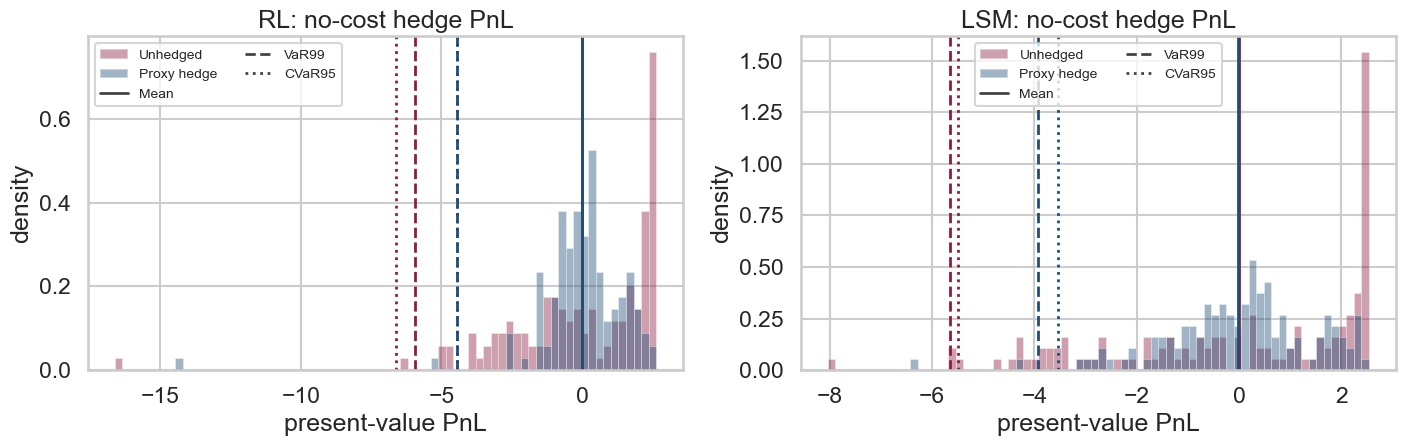

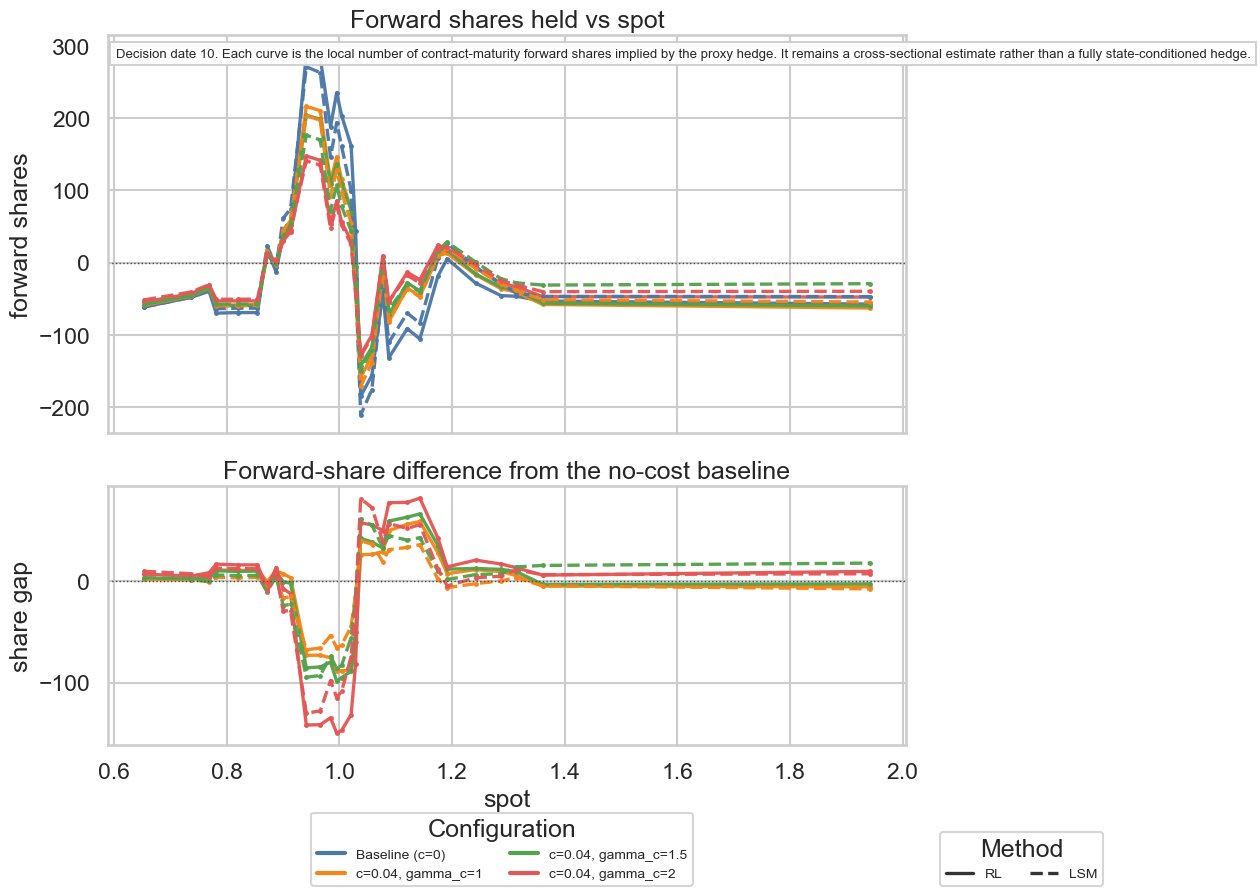

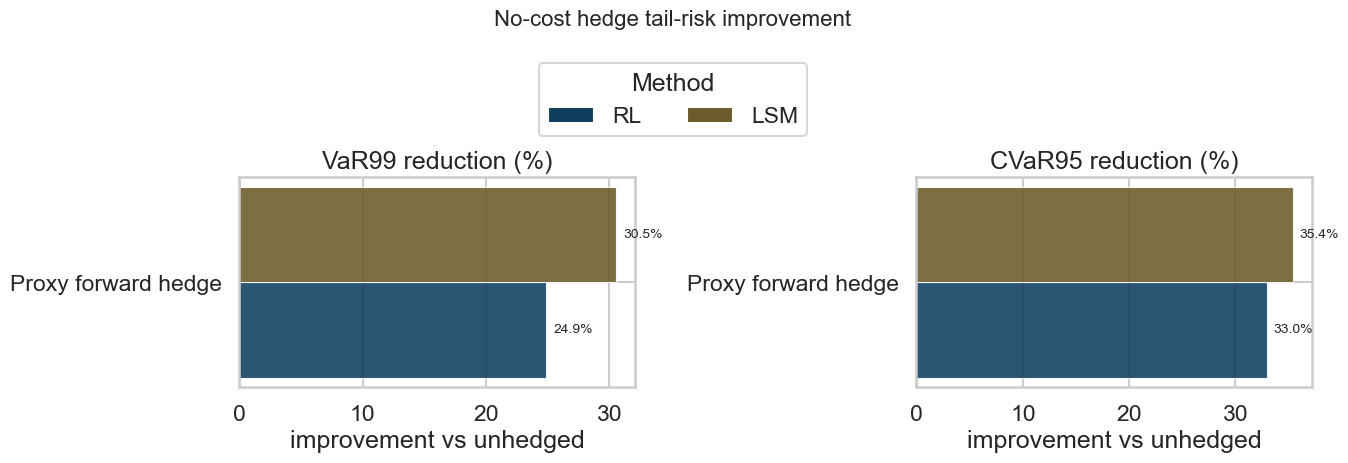

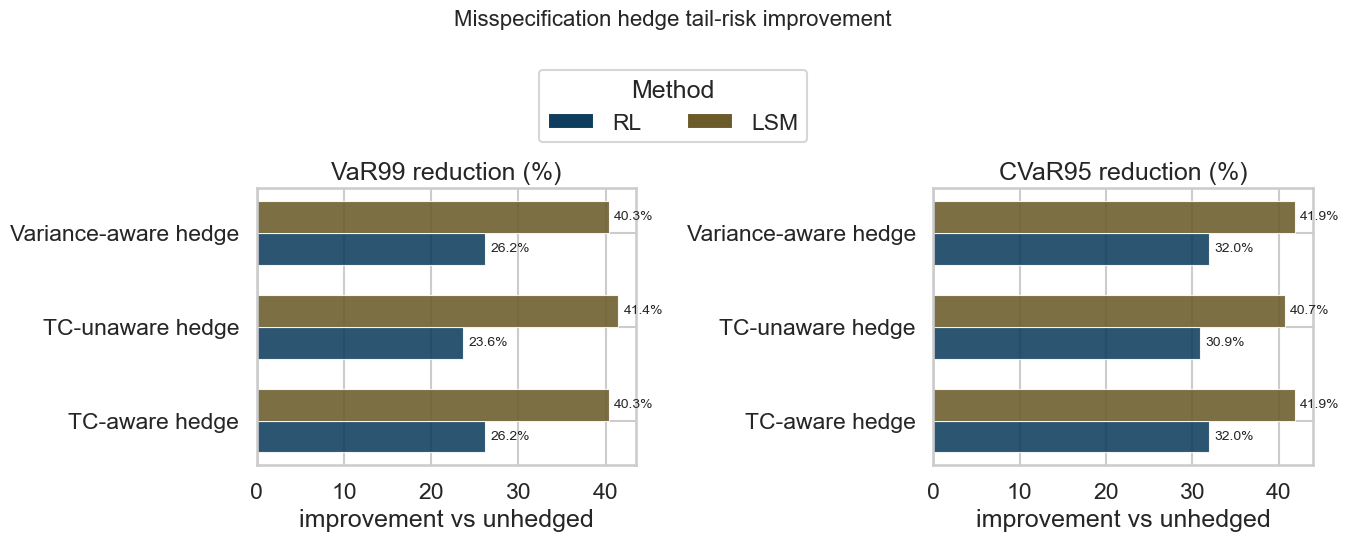

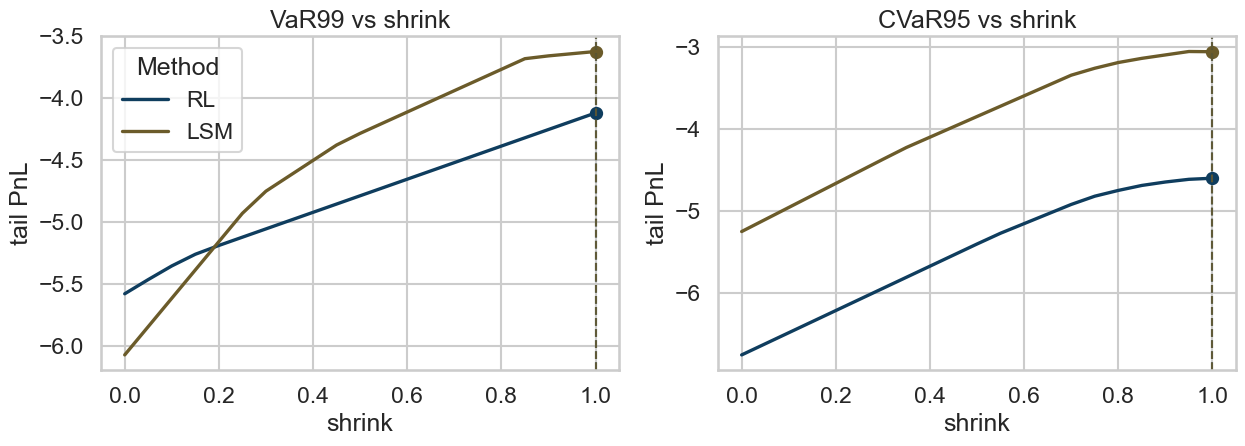


Section 5 summary tables


In [7]:
def local_delta_curve(panel_subset: pd.DataFrame, time_step: int, bins: int = 30) -> pd.DataFrame:
    slice_df = panel_subset[panel_subset["time_step"] == time_step].copy()
    if slice_df.empty:
        raise ValueError(f"No rows found at time_step={time_step}")
    overall_delta = ols_slope(slice_df["hedge_basis"], slice_df["remaining_pv"])
    max_bins = max(8, min(bins, max(8, len(slice_df) // 3)))
    slice_df["spot_bin"] = pd.qcut(slice_df["spot"], q=max_bins, duplicates="drop")
    rows = []
    for _, group in slice_df.groupby("spot_bin", observed=True, sort=True):
        delta = ols_slope(group["hedge_basis"], group["remaining_pv"])
        rows.append(
            {
                "spot_mid": float(group["spot"].mean()),
                "forward_shares": 0.0 if np.isnan(delta) else float(delta),
                "n_obs": int(len(group)),
            }
        )
    if not rows:
        rows.append(
            {
                "spot_mid": float(slice_df["spot"].mean()),
                "forward_shares": 0.0 if np.isnan(overall_delta) else float(overall_delta),
                "n_obs": int(len(slice_df)),
            }
        )
    curve_df = pd.DataFrame(rows).sort_values("spot_mid").reset_index(drop=True)
    curve_df["forward_shares_smooth"] = curve_df["forward_shares"].rolling(
        DELTA_SMOOTH_WINDOW,
        center=True,
        min_periods=1,
    ).mean()
    return curve_df


def _format_metric_value(value: float) -> str:
    return f"{value:,.3f}"


def _hex_to_rgb(hex_color: str) -> tuple[int, int, int]:
    hex_color = hex_color.lstrip("#")
    return tuple(int(hex_color[idx : idx + 2], 16) for idx in (0, 2, 4))


def _rgb_to_hex(rgb: tuple[float, float, float]) -> str:
    clipped = tuple(int(np.clip(channel, 0, 255)) for channel in rgb)
    return f"#{clipped[0]:02x}{clipped[1]:02x}{clipped[2]:02x}"


def _interp_color(color_lo: str, color_hi: str, weight: float) -> str:
    lo = np.asarray(_hex_to_rgb(color_lo), dtype=np.float64)
    hi = np.asarray(_hex_to_rgb(color_hi), dtype=np.float64)
    weight = float(np.clip(weight, 0.0, 1.0))
    rgb = (1.0 - weight) * lo + weight * hi
    return _rgb_to_hex(tuple(rgb))


def _relative_luminance(hex_color: str) -> float:
    def convert(channel: float) -> float:
        channel = channel / 255.0
        return channel / 12.92 if channel <= 0.04045 else ((channel + 0.055) / 1.055) ** 2.4

    rgb = _hex_to_rgb(hex_color)
    r_lin, g_lin, b_lin = (convert(float(value)) for value in rgb)
    return 0.2126 * r_lin + 0.7152 * g_lin + 0.0722 * b_lin


def build_bootstrap_summary_table(
    method_pnls: Dict[str, Dict[str, np.ndarray]],
    *,
    scenario_order: Sequence[str],
    scenario_labels: Dict[str, str],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    metrics = [
        ("Mean PnL", "mean_pnl"),
        ("VaR99", "var_pnl_99"),
        ("CVaR95", "cvar_pnl_95"),
    ]
    display_columns = []
    raw_columns = []
    for method in METHODS:
        for metric_label, metric_key in metrics:
            display_columns.append((method, metric_label))
            raw_columns.append((method, metric_key))

    display_df = pd.DataFrame(
        index=[scenario_labels[key] for key in scenario_order],
        columns=pd.MultiIndex.from_tuples(display_columns),
    )
    raw_df = pd.DataFrame(
        index=[scenario_labels[key] for key in scenario_order],
        columns=pd.MultiIndex.from_tuples(raw_columns),
        dtype=float,
    )

    for method in METHODS:
        for scenario_key in scenario_order:
            pnl = method_pnls[method][scenario_key]
            summary = summarize_pnl_distribution(pnl)
            for metric_label, metric_key in metrics:
                display_df.loc[scenario_labels[scenario_key], (method, metric_label)] = _format_metric_value(
                    summary[metric_key]
                )
                raw_df.loc[scenario_labels[scenario_key], (method, metric_key)] = summary[metric_key]

    return display_df, raw_df


def style_bootstrap_summary_table(display_df: pd.DataFrame, raw_df: pd.DataFrame, caption: str):
    metric_map = {
        "Mean PnL": "mean_pnl",
        "VaR99": "var_pnl_99",
        "CVaR95": "cvar_pnl_95",
    }
    mean_palette = ("#edf7ff", "#0b4f8a")
    risk_palette = ("#fff4e8", "#8a1c1c")
    header_bg = "#f5f1dc"
    index_bg = "#f7f4e7"

    mean_values = []
    risk_values = []
    for method, metric_label in display_df.columns:
        values = raw_df[(method, metric_map[metric_label])].astype(float).tolist()
        if metric_label == "Mean PnL":
            mean_values.extend(values)
        else:
            risk_values.extend(values)

    mean_min, mean_max = float(min(mean_values)), float(max(mean_values))
    risk_min, risk_max = float(min(risk_values)), float(max(risk_values))

    def normalize(value: float, bounds: tuple[float, float]) -> float:
        lower, upper = bounds
        span = max(upper - lower, 1e-8)
        return (float(value) - lower) / span

    def style_cells(_: pd.DataFrame) -> pd.DataFrame:
        styles = pd.DataFrame("", index=display_df.index, columns=display_df.columns)
        for method, metric_label in display_df.columns:
            metric_key = metric_map[metric_label]
            values = raw_df[(method, metric_key)].astype(float)
            for idx, value in values.items():
                if metric_label == "Mean PnL":
                    score = normalize(float(value), (mean_min, mean_max))
                    bg = _interp_color(mean_palette[0], mean_palette[1], score)
                else:
                    score = normalize(float(value), (risk_min, risk_max))
                    bg = _interp_color(risk_palette[0], risk_palette[1], score)
                fg = "#f8fbff" if _relative_luminance(bg) < 0.25 else "#10212b"
                styles.loc[idx, (method, metric_label)] = (
                    f"background-color: {bg}; color: {fg}; font-weight: 700;"
                )
        return styles

    return (
        display_df.style
        .set_caption(caption)
        .apply(style_cells, axis=None)
        .set_table_styles(
            [
                {
                    "selector": "caption",
                    "props": [
                        ("caption-side", "top"),
                        ("font-size", "15px"),
                        ("font-weight", "700"),
                        ("text-align", "left"),
                        ("color", "#1d2733"),
                    ],
                },
                {
                    "selector": "th",
                    "props": [
                        ("text-align", "center"),
                        ("font-weight", "700"),
                        ("background-color", header_bg),
                        ("color", "#1d2733"),
                        ("border", "1px solid #ddd5b5"),
                    ],
                },
                {
                    "selector": ".row_heading",
                    "props": [
                        ("background-color", index_bg),
                        ("color", "#1d2733"),
                        ("font-weight", "700"),
                    ],
                },
                {
                    "selector": "td",
                    "props": [
                        ("text-align", "center"),
                        ("padding", "8px 10px"),
                        ("white-space", "nowrap"),
                        ("border", "1px solid #ddd5b5"),
                    ],
                },
                {
                    "selector": "table",
                    "props": [
                        ("border-collapse", "collapse"),
                        ("background-color", "#fbf9ef"),
                    ],
                },
            ]
        )
    )


def plot_delta_curves(delta_df: pd.DataFrame, time_step: int) -> None:
    line_styles = {"RL": "-", "LSM": "--"}
    fig, axes = plt.subplots(
        2,
        1,
        figsize=(11.8, 9.2),
        sharex=True,
        gridspec_kw={"height_ratios": [2.0, 1.3]},
    )
    ax_top, ax_bottom = axes

    for method in METHODS:
        base_curve = delta_df[
            (delta_df["method"] == method) & (delta_df["config"] == NO_COST_BASELINE)
        ].sort_values("spot_mid")
        base_x = base_curve["spot_mid"].to_numpy(dtype=np.float64)
        base_y = base_curve["forward_shares_smooth"].to_numpy(dtype=np.float64)
        for config in BUILD_CONFIGS:
            subset = delta_df[
                (delta_df["method"] == method) & (delta_df["config"] == config)
            ].sort_values("spot_mid")
            if subset.empty:
                continue
            color = CONFIG_PALETTE.get(config, PLOT_COLORS[method])
            smooth_y = subset["forward_shares_smooth"].to_numpy(dtype=np.float64)
            ax_top.plot(
                subset["spot_mid"],
                smooth_y,
                color=color,
                linestyle=line_styles[method],
                linewidth=2.4,
                marker="o",
                markersize=2.5,
                alpha=0.97,
            )
            if config != NO_COST_BASELINE and base_x.size >= 2:
                base_interp = np.interp(subset["spot_mid"].to_numpy(dtype=np.float64), base_x, base_y)
                share_diff = smooth_y - base_interp
                ax_bottom.plot(
                    subset["spot_mid"],
                    share_diff,
                    color=color,
                    linestyle=line_styles[method],
                    linewidth=2.4,
                    marker="o",
                    markersize=2.5,
                    alpha=0.97,
                )

    ax_top.set_title("Forward shares held vs spot")
    ax_top.set_ylabel("forward shares")
    ax_top.text(
        0.01,
        0.97,
        (
            f"Decision date {time_step}. Each curve is the local number of contract-maturity forward shares implied by the proxy hedge. "
            "It remains a cross-sectional estimate rather than a fully state-conditioned hedge." 
        ),
        transform=ax_top.transAxes,
        ha="left",
        va="top",
        fontsize=9.5,
        bbox={"facecolor": "white", "alpha": 0.9, "edgecolor": "#cccccc"},
    )
    ax_top.axhline(0.0, color="#4a4a4a", linestyle=":", linewidth=1)

    ax_bottom.set_title("Forward-share difference from the no-cost baseline")
    ax_bottom.set_xlabel("spot")
    ax_bottom.set_ylabel("share gap")
    ax_bottom.axhline(0.0, color="#4a4a4a", linestyle=":", linewidth=1)

    config_handles = [
        Line2D([0], [0], color=CONFIG_PALETTE[config], linewidth=3, label=format_config_label(config))
        for config in BUILD_CONFIGS
    ]
    method_handles = [
        Line2D([0], [0], color="#333333", linewidth=2.4, linestyle=line_styles[method], label=method)
        for method in METHODS
    ]
    fig.legend(
        handles=config_handles,
        title="Configuration",
        loc="lower center",
        bbox_to_anchor=(0.44, 0.01),
        ncol=2,
        frameon=True,
        fontsize=10,
    )
    fig.legend(
        handles=method_handles,
        title="Method",
        loc="lower center",
        bbox_to_anchor=(0.88, 0.01),
        ncol=2,
        frameon=True,
        fontsize=10,
    )
    plt.tight_layout(rect=[0, 0.07, 1, 1])
    plt.show()


manifest_path = ensure_cache(BUILD_CONFIG, force=FORCE_REBUILD)
manifest_df = load_manifest(CACHE_ROOT, configs=BUILD_CONFIGS)
trace_df = load_trace_tables(manifest_df)
panel_df = prepare_panel(trace_df)

print("Manifest summary")
print(manifest_df.to_string(index=False))

no_cost_rows = []
no_cost_pnls: Dict[str, Dict[str, np.ndarray]] = {}
for method in METHODS:
    method_panel = panel_df[(panel_df["config"] == NO_COST_BASELINE) & (panel_df["method"] == method)].copy()
    if method_panel.empty:
        continue
    schedule_df = time_step_proxy_schedule(method_panel)
    unhedged, premium = unhedged_pnl(method_panel)
    hedged, premium = simulate_hedge_pnl(method_panel, schedule_df)
    no_cost_pnls[method] = {"unhedged": unhedged, "hedged": hedged}
    no_cost_rows.append(asdict(risk_row("No-cost vanilla", method, "unhedged liability", unhedged, premium)))
    no_cost_rows.append(asdict(risk_row("No-cost vanilla", method, "proxy forward hedge", hedged, premium)))

no_cost_df = pd.DataFrame(no_cost_rows)
no_cost_table_df, no_cost_table_raw = build_bootstrap_summary_table(
    no_cost_pnls,
    scenario_order=["unhedged", "hedged"],
    scenario_labels=NO_COST_SCENARIO_LABELS,
)
no_cost_effectiveness_df = build_tail_risk_reduction_table(
    no_cost_pnls,
    scenario_order=["unhedged", "hedged"],
    scenario_labels=NO_COST_SCENARIO_LABELS,
)
print("\nNo-cost vanilla risk summary")
print(no_cost_effectiveness_df.to_string(index=False))

delta_frames = []
for config in BUILD_CONFIGS:
    for method in METHODS:
        method_panel = panel_df[(panel_df["config"] == config) & (panel_df["method"] == method)].copy()
        if method_panel.empty:
            continue
        curve_df = local_delta_curve(method_panel, DELTA_SLICE_TIME_STEP, DELTA_BINS)
        curve_df["config"] = config
        curve_df["method"] = method
        delta_frames.append(curve_df)

delta_df = pd.concat(delta_frames, ignore_index=True)
print(f"\nForward shares held at decision date {DELTA_SLICE_TIME_STEP}")
print("Each row is the local number of contract-maturity forward shares implied by the proxy hedge.")
print(delta_df.head(36).to_string(index=False))

misspec_frames = []
misspec_pnls: Dict[str, Dict[str, np.ndarray]] = {}
va_shrinks: Dict[str, float] = {}
va_grids: Dict[str, pd.DataFrame] = {}
for method in METHODS:
    misspec_df_method, pnl_store, va_shrink, grid_df = build_misspecification_results(panel_df, method)
    misspec_frames.append(misspec_df_method)
    misspec_pnls[method] = pnl_store
    va_shrinks[method] = va_shrink
    va_grids[method] = grid_df

misspec_df = pd.concat(misspec_frames, ignore_index=True)
misspec_table_df, misspec_table_raw = build_bootstrap_summary_table(
    misspec_pnls,
    scenario_order=["unhedged", "tc-aware", "tc-unaware", "variance-aware"],
    scenario_labels=MISSPEC_SCENARIO_LABELS,
)
misspec_effectiveness_df = build_tail_risk_reduction_table(
    misspec_pnls,
    scenario_order=["unhedged", "tc-aware", "tc-unaware", "variance-aware"],
    scenario_labels=MISSPEC_SCENARIO_LABELS,
)
print("\nTC misspecification tail-risk summary")
print(misspec_effectiveness_df.to_string(index=False))
print("\nVariance-aware shrink choices")
for method, shrink in va_shrinks.items():
    print(f"{method}: {shrink:.2f}")

plot_pnl_histograms(no_cost_pnls)
plot_delta_curves(delta_df, DELTA_SLICE_TIME_STEP)
plot_tail_risk_reduction(no_cost_effectiveness_df, "No-cost hedge tail-risk improvement")
plot_tail_risk_reduction(misspec_effectiveness_df, "Misspecification hedge tail-risk improvement")
plot_variance_aware_grid(va_grids, va_shrinks)

REVIEW_POINTS = build_review_list(no_cost_effectiveness_df, va_shrinks)
NOTEBOOK_OUTPUTS = {
    "manifest": manifest_df,
    "trace_df": trace_df,
    "panel_df": panel_df,
    "no_cost_df": no_cost_df,
    "no_cost_table_df": no_cost_table_df,
    "no_cost_table_raw": no_cost_table_raw,
    "no_cost_effectiveness_df": no_cost_effectiveness_df,
    "delta_df": delta_df,
    "misspec_df": misspec_df,
    "misspec_table_df": misspec_table_df,
    "misspec_table_raw": misspec_table_raw,
    "misspec_effectiveness_df": misspec_effectiveness_df,
    "va_shrinks": va_shrinks,
    "va_grids": va_grids,
    "review_points": REVIEW_POINTS,
}

print("\nSection 5 summary tables")
display(style_bootstrap_summary_table(no_cost_table_df, no_cost_table_raw, "No-cost vanilla hedge summary"))
display(style_bootstrap_summary_table(misspec_table_df, misspec_table_raw, "Transaction-cost misspecification summary"))

### Clean t=0 S0 Sweep

The shared-path cache used above starts from a single initial `S0`, so it cannot identify a clean cross-sectional `t=0` hedge curve by itself. This notebook therefore loads the saved `delta_sweep.sh` artifacts as a complementary analysis slice within the same Section 5 workflow.

Interpret the `tc_premium` panel as the no-cost baseline premium minus the convex-cost premium on the same `S0` grid. The `delta_t0` and `gamma_t0` panels are computed by finite differences on a Gaussian-process-smoothed PV curve, so they are both interpolated and visibly smoother than the raw finite-difference estimates. Gamma remains more noise-sensitive than premium or delta and should still be treated as exploratory rather than headline evidence.


Saved t=0 S0 sweep assessment
CSV: /Users/alexanderithakis/Documents/GitHub/DRL-Swing-Options/logs/hedging_s0_sweep/s0_greeks_summary.csv
PNG: /Users/alexanderithakis/Documents/GitHub/DRL-Swing-Options/logs/hedging_s0_sweep/s0_greeks_summary.png
Gamma is recomputed with centered three-point stencils and one-sided three-point edge windows.
Status counts:
status
usable-with-caveat    8


,method,config_label,target_s0,premium_at_target_s0,tc_premium_at_target_s0,delta_at_target_s0,gamma_at_target_s0,rl_lsm_gap_at_target_s0,rl_seed_count,status,caveat
0,LSM,Baseline (c=0),1.00,2.686,0.000,8.36,15.65,-0.051,0,usable-with-caveat,local delta dip -0.13
1,LSM,"c=0.04, gamma_c=1",1.00,2.244,0.442,7.46,16.19,-0.018,0,usable-with-caveat,local delta dip -0.13
2,LSM,"c=0.04, gamma_c=1.5",1.00,2.114,0.572,7.19,16.13,-0.025,0,usable-with-caveat,local delta dip -0.13
3,LSM,"c=0.04, gamma_c=2",1.00,1.997,0.689,6.96,15.79,-0.016,0,usable-with-caveat,local delta dip -0.12
4,RL,Baseline (c=0),1.00,2.635,0.000,8.23,16.19,-0.051,1,usable-with-caveat,local delta dip -0.13; RL seeds 1 vs peer max 3
5,RL,"c=0.04, gamma_c=1",1.00,2.226,0.409,7.40,16.19,-0.018,3,usable-with-caveat,local delta dip -0.13
6,RL,"c=0.04, gamma_c=1.5",1.00,2.089,0.546,7.09,15.92,-0.025,3,usable-with-caveat,local delta dip -0.13
7,RL,"c=0.04, gamma_c=2",1.00,1.981,0.654,6.92,15.66,-0.016,3,usable-with-caveat,local delta dip -0.12


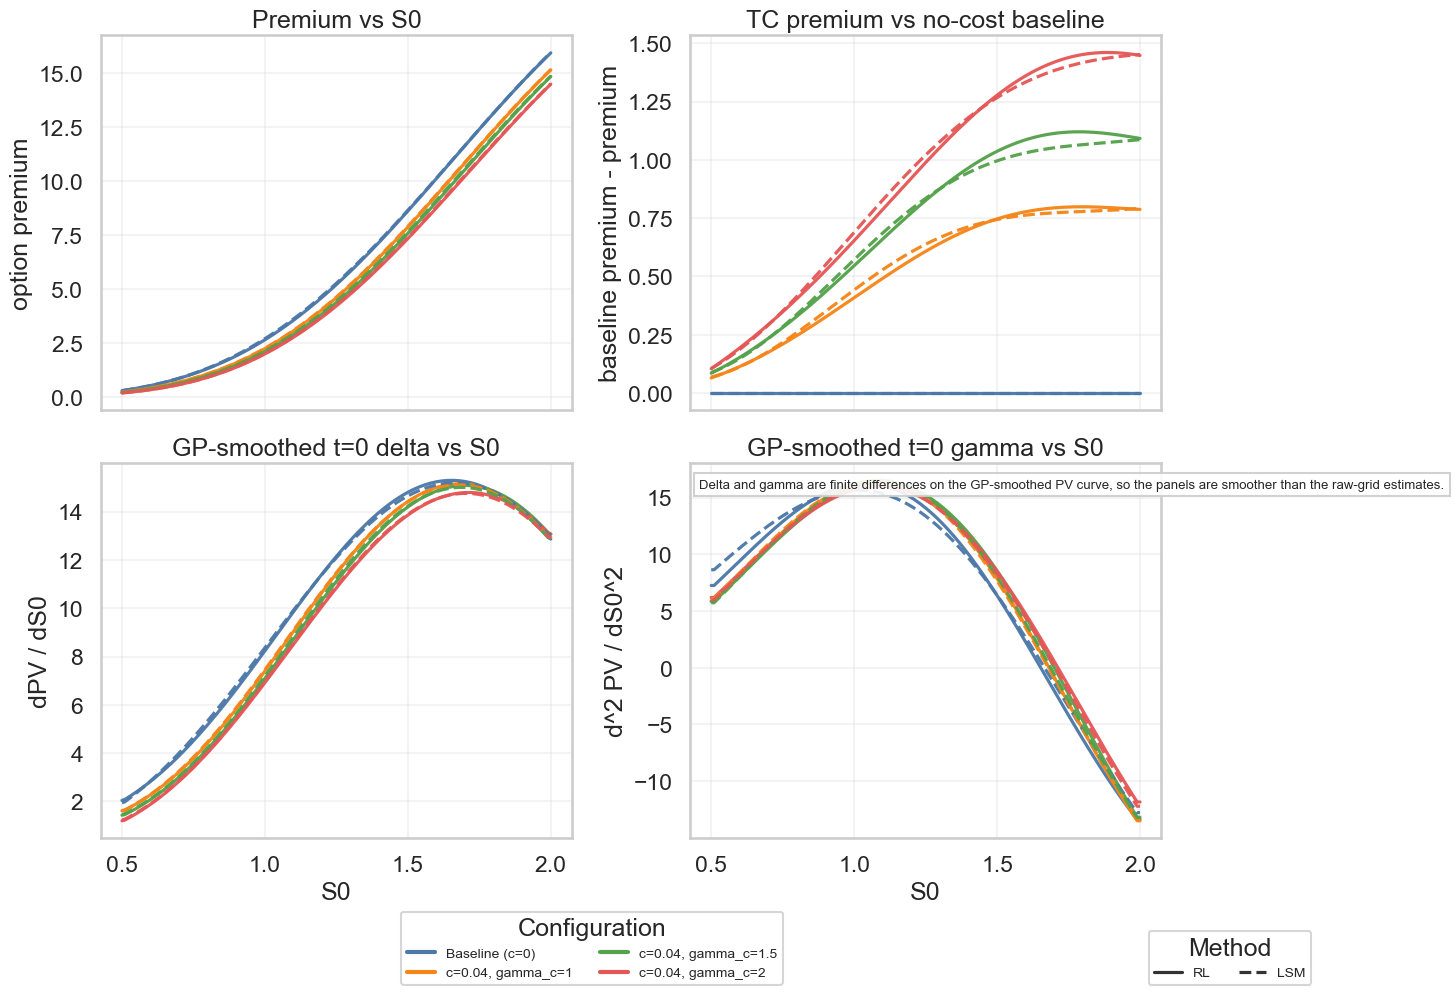

In [8]:
def recompute_gamma_with_edge_stencils(sweep_df: pd.DataFrame) -> pd.DataFrame:
    adjusted = sweep_df.copy()
    updated_frames = []
    for (method, config), group in adjusted.groupby(["method", "config"], sort=False):
        ordered = group.sort_values("s0").copy()
        s0_values = ordered["s0"].to_numpy(dtype=np.float64)
        premium_values = ordered["premium"].to_numpy(dtype=np.float64)
        if s0_values.size < 3:
            raise ValueError(f"Need at least three S0 points for {method}/{config}")

        gamma_values = np.empty_like(premium_values)
        last_idx = s0_values.size - 1
        for idx in range(s0_values.size):
            if idx == 0:
                window = slice(0, 3)
            elif idx == last_idx:
                window = slice(last_idx - 2, last_idx + 1)
            else:
                window = slice(idx - 1, idx + 2)
            coeffs = np.polyfit(s0_values[window], premium_values[window], deg=2)
            gamma_values[idx] = 2.0 * float(coeffs[0])

        ordered.loc[:, "gamma_t0"] = gamma_values
        updated_frames.append(ordered)

    updated_df = pd.concat(updated_frames, ignore_index=True)
    return updated_df.sort_values(["method", "config", "s0"]).reset_index(drop=True)


def style_s0_sweep_assessment_dark(assessment_df: pd.DataFrame):
    format_map = {
        "target_s0": "{:.2f}",
        "premium_at_target_s0": "{:.3f}",
        "tc_premium_at_target_s0": "{:.3f}",
        "delta_at_target_s0": "{:.2f}",
        "gamma_at_target_s0": "{:.2f}",
        "rl_lsm_gap_at_target_s0": "{:.3f}",
        "rl_seed_count": "{:.0f}",
    }
    status_colors = {
        "usable": "#123524",
        "usable-with-caveat": "#3a2f12",
        "rerun-needed": "#40171f",
    }
    table_bg = "#0f141c"
    header_bg = "#1b2430"
    border_color = "#344255"
    caption_color = "#e7edf7"
    body_text = "#f7fafc"

    def row_style(row: pd.Series) -> list[str]:
        base_color = status_colors.get(row["status"], table_bg)
        return [
            (
                f"background-color: {base_color}; color: {body_text}; "
                f"border: 1px solid {border_color}; font-weight: 600;"
            )
            for _ in row
        ]

    return (
        assessment_df.style
        .apply(row_style, axis=1)
        .format(format_map)
        .set_caption("Saved t=0 S0 sweep assessment")
        .set_table_styles(
            [
                {
                    "selector": "caption",
                    "props": [
                        ("caption-side", "top"),
                        ("font-size", "15px"),
                        ("font-weight", "700"),
                        ("text-align", "left"),
                        ("color", caption_color),
                        ("padding", "0 0 8px 2px"),
                    ],
                },
                {
                    "selector": "table",
                    "props": [
                        ("border-collapse", "collapse"),
                        ("background-color", table_bg),
                        ("color", body_text),
                        ("table-layout", "auto"),
                        ("width", "100%"),
                    ],
                },
                {
                    "selector": "th",
                    "props": [
                        ("background-color", header_bg),
                        ("color", body_text),
                        ("border", f"1px solid {border_color}"),
                        ("font-weight", "700"),
                        ("text-align", "center"),
                        ("padding", "10px 12px"),
                        ("white-space", "nowrap"),
                    ],
                },
                {
                    "selector": "td",
                    "props": [
                        ("border", f"1px solid {border_color}"),
                        ("text-align", "center"),
                        ("padding", "8px 12px"),
                        ("white-space", "nowrap"),
                        ("color", body_text),
                    ],
                },
                {
                    "selector": ".row_heading",
                    "props": [
                        ("background-color", header_bg),
                        ("color", body_text),
                        ("font-weight", "700"),
                        ("border", f"1px solid {border_color}"),
                    ],
                },
            ]
        )
    )


s0_sweep_output_dir = globals().get(
    "S0_SWEEP_OUTPUT_DIR",
    REPO_ROOT / "logs" / "hedging_s0_sweep",
)
s0_sweep_csv = globals().get("S0_SWEEP_CSV", s0_sweep_output_dir / "s0_greeks_summary.csv")
s0_sweep_png = globals().get("S0_SWEEP_PNG", s0_sweep_output_dir / "s0_greeks_summary.png")

s0_sweep_df = load_s0_sweep_results(s0_sweep_csv)
s0_sweep_df = recompute_gamma_with_edge_stencils(s0_sweep_df)
s0_sweep_assessment_df, s0_sweep_diagnostics_df = build_s0_sweep_assessment(s0_sweep_df)

s0_sweep_display_columns = [
    "method",
    "config_label",
    "target_s0",
    "premium_at_target_s0",
    "tc_premium_at_target_s0",
    "delta_at_target_s0",
    "gamma_at_target_s0",
    "rl_lsm_gap_at_target_s0",
    "rl_seed_count",
    "status",
    "caveat",
]

print("\nSaved t=0 S0 sweep assessment")
print(f"CSV: {s0_sweep_csv}")
print(f"PNG: {s0_sweep_png}")
print("Gamma is recomputed with centered three-point stencils and one-sided three-point edge windows.")
print("Status counts:")
print(s0_sweep_assessment_df["status"].value_counts().to_string())

display(style_s0_sweep_assessment_dark(s0_sweep_assessment_df[s0_sweep_display_columns]))
plot_s0_sweep_results(s0_sweep_df)

NOTEBOOK_OUTPUTS["s0_sweep_df"] = s0_sweep_df
NOTEBOOK_OUTPUTS["s0_sweep_assessment_df"] = s0_sweep_assessment_df
NOTEBOOK_OUTPUTS["s0_sweep_diagnostics_df"] = s0_sweep_diagnostics_df
NOTEBOOK_OUTPUTS["s0_sweep_csv"] = s0_sweep_csv
NOTEBOOK_OUTPUTS["s0_sweep_png"] = s0_sweep_png

## 6. Validate with Basic Checks

Confirm that the cache schema is intact, that the minimal run produced non-empty sections, and print a 10-point improvement list based on the first-pass results.

In [9]:
assert manifest_path.exists()
assert not NOTEBOOK_OUTPUTS["manifest"].empty
assert REQUIRED_TRACE_COLUMNS.issubset(NOTEBOOK_OUTPUTS["trace_df"].columns)
assert np.isfinite(NOTEBOOK_OUTPUTS["trace_df"]["forward_contract_maturity"]).all()
assert not NOTEBOOK_OUTPUTS["no_cost_df"].empty
assert not NOTEBOOK_OUTPUTS["no_cost_table_df"].empty
assert not NOTEBOOK_OUTPUTS["misspec_df"].empty
assert not NOTEBOOK_OUTPUTS["misspec_table_df"].empty
assert not NOTEBOOK_OUTPUTS["no_cost_effectiveness_df"].empty
assert not NOTEBOOK_OUTPUTS["misspec_effectiveness_df"].empty
assert len(NOTEBOOK_OUTPUTS["review_points"]) == 10

path_monotone = NOTEBOOK_OUTPUTS["panel_df"].groupby(["config", "method", "seed", "path"], sort=False)["time_step"].apply(
    lambda s: bool(np.all(np.diff(s.to_numpy(dtype=np.int64)) >= 0))
)
assert path_monotone.all()
assert np.isfinite(NOTEBOOK_OUTPUTS["no_cost_table_raw"].to_numpy(dtype=np.float64)).all()
assert np.isfinite(NOTEBOOK_OUTPUTS["misspec_table_raw"].to_numpy(dtype=np.float64)).all()
assert np.isfinite(NOTEBOOK_OUTPUTS["no_cost_effectiveness_df"]["var99_reduction_pct"]).all()
assert np.isfinite(NOTEBOOK_OUTPUTS["no_cost_effectiveness_df"]["cvar95_reduction_pct"]).all()
assert np.isfinite(NOTEBOOK_OUTPUTS["misspec_effectiveness_df"]["var99_reduction_pct"]).all()
assert np.isfinite(NOTEBOOK_OUTPUTS["misspec_effectiveness_df"]["cvar95_reduction_pct"]).all()

print("Basic checks passed.")
print("\n10 improvements to carry into the next hedge iteration:")
for idx, item in enumerate(NOTEBOOK_OUTPUTS["review_points"], start=1):
    print(f"{idx}. {item}")

Basic checks passed.

10 improvements to carry into the next hedge iteration:
1. Move the RL proxy hedge calibration out of sample; in smoke mode the no-cost hedge improves CVaR95 by only about 33.0%, which is not enough to support a strong claim without held-out testing.
2. Move the LSM proxy hedge calibration out of sample; in smoke mode the no-cost hedge improves CVaR95 by only about 35.4%, which is not enough to support a strong claim without held-out testing.
3. Replace the current time-step-only schedule with a state-conditional hedge that uses spot, X_t, Y_t, remaining volume, and days-since-exercise together.
4. Estimate hedge deltas on a larger shared path set; the smoke notebook is useful for iteration, but the reported curves need a production rerun at the canonical path counts.
5. Separate hedge-fit paths from hedge-evaluation paths so the tc-aware, tc-unaware, and variance-aware comparisons are not all in-sample.
6. Add multiple hedge instruments, starting with a short str